In [48]:
filt_conds = dict(
    Ms_min = 2e10,          # M_sol
    Ms_max = 5e11,          # M_sol
    r_min = 500,            # kpc
    r_max = 1000,           # kpc
    vt_min = 0,             # km/s
    vt_max = 300,           # km/s
    vr_min= -400,           # km/s
    vr_max = 0,             # km/s
    third_massive_m = 1.0,  # factor
    intruder_r = 1500,      # kpc
    intruder_m = 0.5        # factor
)

filts = dict()

In [49]:
import os
import numpy as np
import matplotlib.pyplot as plt
import illustris_python as il

from lg_analogues import (
    load_header_constants,
    select_central_plus_largest_satellite_by_stellar_mass,
    find_pairs_periodic,
    isolation_filter_no_third_factor_x_in_same_group,
    isolation_filter_no_massive_intruder_within_distance_x,
    calculate_force_ratio,
    compute_tidal_dominance
)

basePath = os.path.expanduser("~/dsp26/dsp-cosmology")
snap = 99

In [50]:
# Load header constants (h and box size)
const = load_header_constants(basePath, snap)
h = const["h"]
box = const["box_ckpch"]

print("h:", h)
print("BoxSize [ckpc/h]:", box)

h: 0.6774
BoxSize [ckpc/h]: 205000.0


In [51]:
# Load subhalo fields needed for selection and pair finding
subhalo_fields = [ 
    "SubhaloPos",       
    "SubhaloVel",       
    "SubhaloMass",      
    "SubhaloMassType",  
    "SubhaloSFRinRad", 
    "SubhaloFlag",      
    "SubhaloGrNr",       
    "SubhaloMass",
    "SubhaloMassInRadType"
]

sub = il.groupcat.loadSubhalos(basePath, snap, fields=subhalo_fields)
print("All subhalos:", sub["count"])

All subhalos: 14485709


In [52]:
# Selection: centrals with stellar mass in window, plus largest satellite in window (per FoF group)
sample = select_central_plus_largest_satellite_by_stellar_mass(
    sub=sub,
    basePath=basePath,
    snap=snap,
    h=h,
    mstar_min=filt_conds["Ms_min"],
    mstar_max=filt_conds["Ms_max"],
)

print("Sample size:", sample.pos.shape[0])
print(f"Stellar mass range : [{float(sample.mstar.min()):.3e}, {float(sample.mstar.max()):.3e}] M_sol")
print("Groups represented:", np.unique(sample.grnr).size)

Sample size: 45392
Stellar mass range : [2.000e+10, 4.999e+11] M_sol
Groups represented: 38778


<>:30: SyntaxWarning: invalid escape sequence '\o'
<>:31: SyntaxWarning: invalid escape sequence '\o'
<>:30: SyntaxWarning: invalid escape sequence '\o'
<>:31: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_7267/675417678.py:30: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel("Total mass [$M_\odot$]", fontsize=12)
/tmp/ipykernel_7267/675417678.py:31: SyntaxWarning: invalid escape sequence '\o'
  plt.ylabel("Stellar mass [$M_\odot$]", fontsize=12)


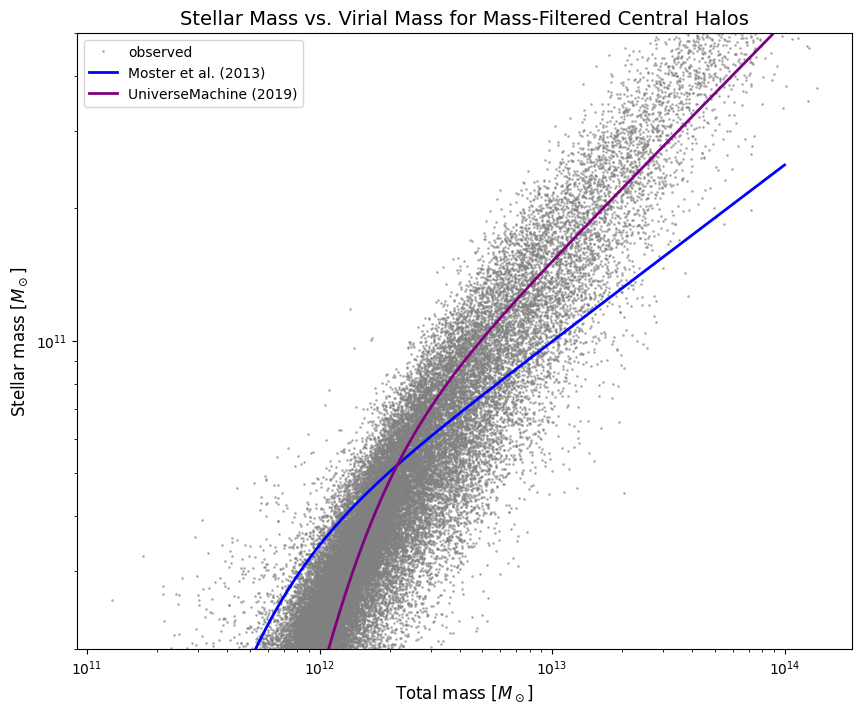

In [53]:
ms_data = sample.mstar.astype(np.float64)[sample.is_central]
mh_data = sample.m200c.astype(np.float64)[sample.is_central]

def moster_func(logMh, logM1, N, beta, gamma):
    Mh = 10**logMh
    M1 = 10**logM1
    ratio = 2 * N * ((Mh/M1)**(-beta) + (Mh/M1)**gamma)**(-1)
    return np.log10(ratio * Mh)

moster = [11.59, 0.035, 1.37, 0.60]
log_x_range_moster = np.linspace(11.7, 14, 100) 

um = [12.09, 0.02, 1.83, 0.46]
log_x_range_um = np.linspace(12, 14, 100)

x_plot_moster = 10**log_x_range_moster
y_plot_moster = 10**moster_func(log_x_range_moster, *moster)

x_plot_um = 10**log_x_range_um
y_plot_um = 10**moster_func(log_x_range_um, *um)

plt.figure(figsize=(10,8))

plt.plot(mh_data, ms_data, ".", markersize=2.0, alpha=0.5, color="gray", label="observed")
plt.plot(x_plot_moster, y_plot_moster, color='blue', linewidth=2, label="Moster et al. (2013)")
plt.plot(x_plot_um, y_plot_um, color='purple', linewidth=2, label="UniverseMachine (2019)")

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Total mass [$M_\odot$]", fontsize=12)
plt.ylabel("Stellar mass [$M_\odot$]", fontsize=12)
plt.ylim(filt_conds["Ms_min"], filt_conds["Ms_max"])
plt.title("Stellar Mass vs. Virial Mass for Mass-Filtered Central Halos", fontsize=14)
plt.legend()

plt.show()

In [54]:
# Pair finding (periodic), 500–1000 kpc
pairs = find_pairs_periodic(
    pos=sample.pos,
    vel=sample.vel,
    grnr=sample.grnr,
    h=h,
    box_ckpch=box,
    r_min_kpc=filt_conds["r_min"],
    r_max_kpc=filt_conds["r_max"],
)

print("Pairs:", pairs.i.size)
print("Same-host pairs:", int(pairs.same_host.sum()))
print("Different-host pairs:", int((~pairs.same_host).sum()))

Pairs: 2655
Same-host pairs: 2084
Different-host pairs: 571


In [55]:
# Isolation filter: no third subhalo in same FoF group(s) >= x 
# times more massive than the larger pair member

mask_group = isolation_filter_no_third_factor_x_in_same_group(
    sub=sub,
    pair_i=pairs.i,
    pair_j=pairs.j,
    sample_grnr=sample.grnr,
    sample_keep_idx_global=sample.keep_idx,
    h=h,
    x=filt_conds["third_massive_m"],
)

print("Pairs after group isolation:", int(mask_group.sum()))

Pairs after group isolation: 2571


In [56]:
# Isolation filter: No subhalos more massive than a `mass_factor`` times the combined
# mass of the pair within `r_iso_kpc` kpc from the center of mass of the pair.

mask_spatial = isolation_filter_no_massive_intruder_within_distance_x(
    sub=sub,
    pair_i=pairs.i,
    pair_j=pairs.j,
    sample_pos=sample.pos,
    sample_keep_idx_global=sample.keep_idx,
    h=h,
    box_ckpch=box,
    r_iso_kpc=filt_conds["intruder_r"],
    mass_factor=filt_conds["intruder_m"]
)

print("Pairs after spatial isolation:", int(mask_spatial.sum()))

Pairs after spatial isolation: 2655


In [57]:
keep_iso =  mask_spatial & mask_group
print(f"Pairs surviving isolation conditions: {np.sum(keep_iso)}")

Pairs surviving isolation conditions: 2571


In [58]:
keep_vel = (
    (pairs.v_t >= filt_conds["vt_min"])
    & (pairs.v_t <= filt_conds["vt_max"])
    & (pairs.v_r >= filt_conds["vr_min"])
    & (pairs.v_r <= filt_conds["vr_max"])
)
print(f"Isolated pairs surviving velocity conditions: {np.sum(keep_vel & keep_iso)}")

Isolated pairs surviving velocity conditions: 1743


In [59]:
f_ratios = calculate_force_ratio(sub, pairs, sample, h, box, search_radius_kpc=filt_conds["intruder_r"])
print(f"Range of force ratios: [{min(f_ratios):.3f}, {max(f_ratios):.3f}]")

internally_dom = f_ratios < 0.5
print(f"Internally dominated isolated pairs: {np.sum(keep_iso & internally_dom)}")

Range of force ratios: [0.035, 5197.234]
Internally dominated isolated pairs: 488


In [60]:
tidally_dom = compute_tidal_dominance(sub, pairs, sample, h, box, search_radius_kpc=filt_conds["intruder_r"])
print(f"Tidally dominant isolated pairs: {np.sum(keep_iso & tidally_dom)}")

Tidally dominant isolated pairs: 952


<>:66: SyntaxWarning: invalid escape sequence '\m'
<>:66: SyntaxWarning: invalid escape sequence '\m'
<>:69: SyntaxWarning: invalid escape sequence '\m'
<>:69: SyntaxWarning: invalid escape sequence '\g'
<>:66: SyntaxWarning: invalid escape sequence '\m'
<>:66: SyntaxWarning: invalid escape sequence '\m'
<>:69: SyntaxWarning: invalid escape sequence '\m'
<>:69: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_7267/399220825.py:66: SyntaxWarning: invalid escape sequence '\m'
  linewidth=2, label=f'$\mathcal{{T}}_{{\mathrm{{sub}}}}$ (N={N_tidal_sub})', bw_adjust=bw)
/tmp/ipykernel_7267/399220825.py:66: SyntaxWarning: invalid escape sequence '\m'
  linewidth=2, label=f'$\mathcal{{T}}_{{\mathrm{{sub}}}}$ (N={N_tidal_sub})', bw_adjust=bw)
/tmp/ipykernel_7267/399220825.py:69: SyntaxWarning: invalid escape sequence '\m'
  linewidth=2, label=f'$\mathcal{{F}} \geq 0.5$ (N={N_ext_dom})', bw_adjust=bw)
/tmp/ipykernel_7267/399220825.py:69: SyntaxWarning: invalid escape sequence '\g'
  li

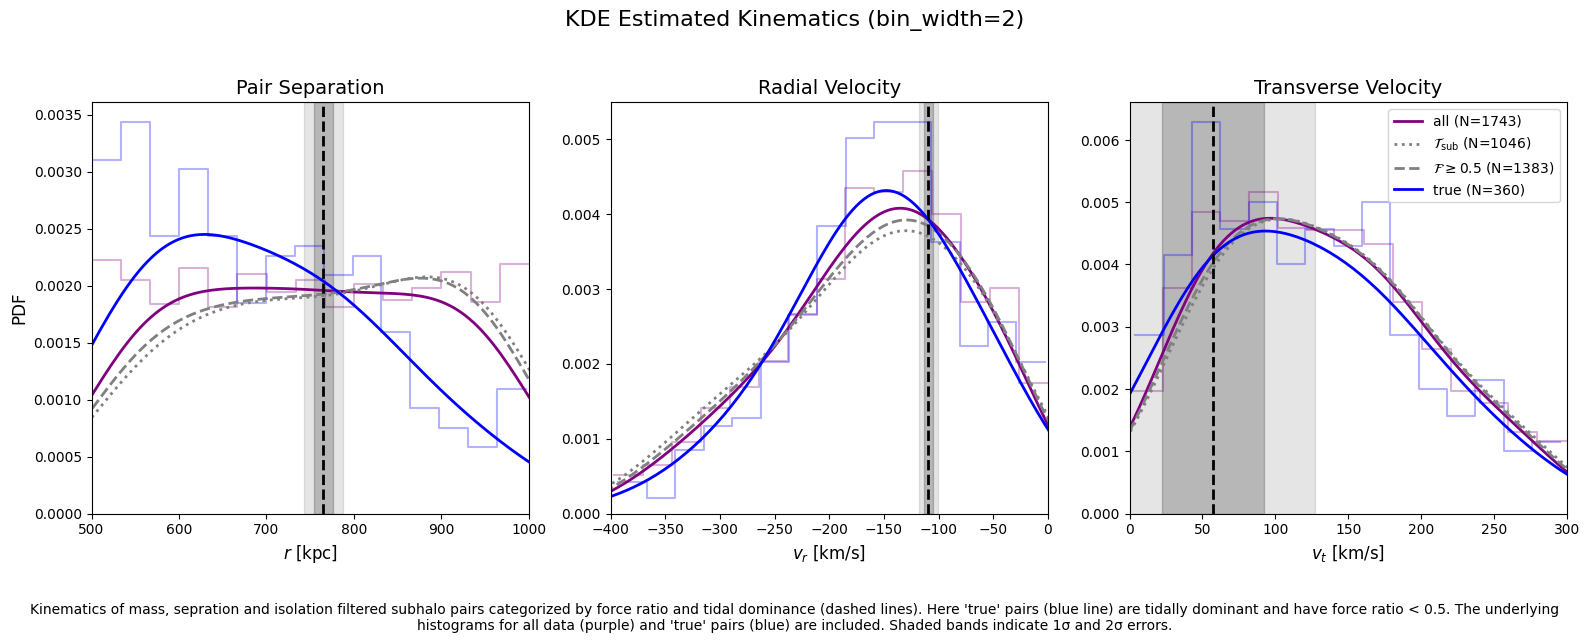

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


dist = pairs.dist_kpc[keep_vel & keep_iso]
vr = pairs.v_r[keep_vel & keep_iso]
vt = pairs.v_t[keep_vel & keep_iso]
bw = 2

# Observational constraints
obs_data = {
    'r':  {'val': 765, 'sigma': 11},
    'vr': {'val': -109.3, 'sigma': 4.4},
    'vt': {'val': 57, 'sigma': 35}
}

fig, axes = plt.subplots(1, 3, figsize=(16, 6), constrained_layout=True)

ranges = {
    'r':  [filt_conds["r_min"], filt_conds["r_max"]],
    'vr': [filt_conds["vr_min"], filt_conds["vr_max"]],
    'vt': [filt_conds["vt_min"], filt_conds["vt_max"]]
}

titles = ["Pair Separation", "Radial Velocity", "Transverse Velocity"]
x_labels = ["$r$ [kpc]", "$v_r$ [km/s]", "$v_t$ [km/s]"]
data_list = [dist, vr, vt]
obs_keys = ['r', 'vr', 'vt']

data_ext_dom = [
    pairs.dist_kpc[keep_vel & keep_iso & ~internally_dom],
    pairs.v_r[keep_vel & keep_iso & ~internally_dom],
    pairs.v_t[keep_vel & keep_iso & ~internally_dom]
]

data_tidal_sub = [
    pairs.dist_kpc[keep_vel & keep_iso & ~tidally_dom],
    pairs.v_r[keep_vel & keep_iso & ~tidally_dom],
    pairs.v_t[keep_vel & keep_iso & ~tidally_dom]
]

data_true = [
    pairs.dist_kpc[keep_vel & keep_iso & internally_dom & tidally_dom],
    pairs.v_r[keep_vel & keep_iso & internally_dom & tidally_dom],
    pairs.v_t[keep_vel & keep_iso & internally_dom & tidally_dom]
]

N_all = len(dist)
N_ext_dom = len(data_ext_dom[0])
N_tidal_sub = len(data_tidal_sub[0])
N_true = len(data_true[0])

for i, key in enumerate(obs_keys):
    sns.histplot(data_list[i], ax=axes[i], color="purple", element="step", 
                 fill=False, stat="density", alpha=0.3, label=None, bins=15)
    
    sns.histplot(data_true[i], ax=axes[i], color="blue", element="step", 
                 fill=False, stat="density", alpha=0.3, linewidth=1.5, label=None, bins=15)
    
    # Plot Simulated Distribution with KDE
    sns.kdeplot(data_list[i], ax=axes[i], color="purple", linestyle='-', 
                linewidth=2, label=f'all (N={N_all})', bw_adjust=bw)
    
    sns.kdeplot(data_tidal_sub[i], ax=axes[i], color="gray", linestyle=':', 
                linewidth=2, label=f'$\mathcal{{T}}_{{\mathrm{{sub}}}}$ (N={N_tidal_sub})', bw_adjust=bw)
    
    sns.kdeplot(data_ext_dom[i], ax=axes[i], color="gray", linestyle='--', 
                linewidth=2, label=f'$\mathcal{{F}} \geq 0.5$ (N={N_ext_dom})', bw_adjust=bw)    
    
    sns.kdeplot(data_true[i], ax=axes[i], color="blue", linestyle='-', 
                linewidth=2, label=f'true (N={N_true})', bw_adjust=bw)
    
    # Set the specific Uchuu limits
    axes[i].set_xlim(ranges[key])
    
    # Observational uncertainty regions
    mu = obs_data[key]['val']
    std = obs_data[key]['sigma']
    
    # 2 Sigma Region - Darker (95% CI)
    axes[i].axvspan(mu - 2*std, mu + 2*std, color='black', alpha=0.1)
    # 1 Sigma Region - Lighter (68% CI)
    axes[i].axvspan(mu - std, mu + std, color='black', alpha=0.2)
    
    # Best-fit vertical line
    axes[i].axvline(mu, color='black', linestyle='--', linewidth=2)
    
    axes[i].set_title(titles[i], fontsize=14)
    axes[i].set_xlabel(x_labels[i], fontsize=12)
    axes[i].set_ylabel("")

axes[0].set_ylabel("PDF", fontsize=12)
axes[2].legend()
plt.suptitle(f"KDE Estimated Kinematics (bin_width={bw})", fontsize=16, y=0.98)

caption = " ".join([
    "Kinematics of mass, sepration and isolation filtered subhalo pairs",
    "categorized by force ratio and tidal dominance (dashed lines).",
    "Here 'true' pairs (blue line) are tidally dominant and have force ratio < 0.5.",
    "The underlying histograms for all data (purple) and 'true' pairs (blue) are included.",
    "Shaded bands indicate 1σ and 2σ errors."
])

plt.figtext(0.5, -0.05, caption, wrap=True, horizontalalignment='center', fontsize=10)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

plt.show()

<>:8: SyntaxWarning: invalid escape sequence '\m'
<>:8: SyntaxWarning: invalid escape sequence '\m'
<>:8: SyntaxWarning: invalid escape sequence '\g'
<>:11: SyntaxWarning: invalid escape sequence '\m'
<>:11: SyntaxWarning: invalid escape sequence '\m'
<>:8: SyntaxWarning: invalid escape sequence '\m'
<>:8: SyntaxWarning: invalid escape sequence '\m'
<>:8: SyntaxWarning: invalid escape sequence '\g'
<>:11: SyntaxWarning: invalid escape sequence '\m'
<>:11: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_7267/2284263631.py:8: SyntaxWarning: invalid escape sequence '\m'
  f_legs = ["$\mathcal{{F}}< 0.5$", f"$\mathcal{{F}} \geq 0.5$"]
/tmp/ipykernel_7267/2284263631.py:8: SyntaxWarning: invalid escape sequence '\m'
  f_legs = ["$\mathcal{{F}}< 0.5$", f"$\mathcal{{F}} \geq 0.5$"]
/tmp/ipykernel_7267/2284263631.py:8: SyntaxWarning: invalid escape sequence '\g'
  f_legs = ["$\mathcal{{F}}< 0.5$", f"$\mathcal{{F}} \geq 0.5$"]
/tmp/ipykernel_7267/2284263631.py:11: SyntaxWarning: inval

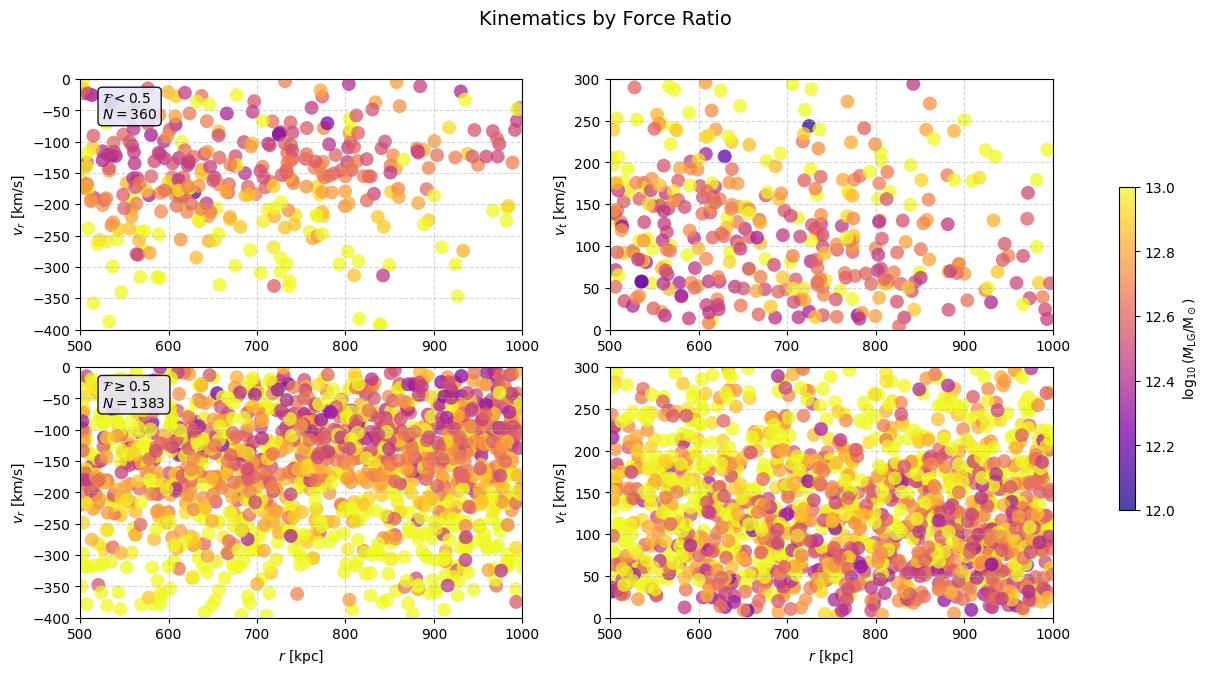

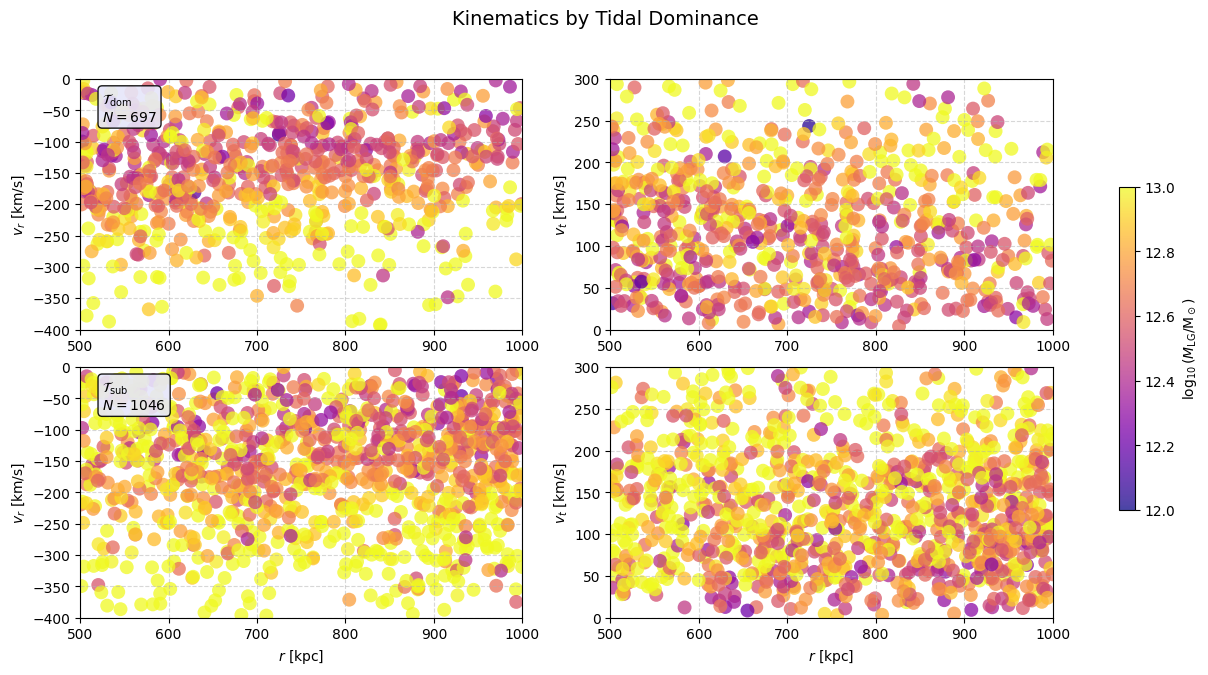

In [62]:
import matplotlib.pyplot as plt
import numpy as np

low_f_mask = (f_ratios < 0.5) & keep_iso & keep_vel
high_f_mask = (f_ratios >= 0.5) & keep_iso & keep_vel

f_masks = [low_f_mask, high_f_mask]
f_legs = ["$\mathcal{{F}}< 0.5$", f"$\mathcal{{F}} \geq 0.5$"]

tid_masks = [tidally_dom & keep_iso & keep_vel, ~tidally_dom & keep_iso & keep_vel]
tid_legs = ["$\mathcal{T}_{\mathrm{{dom}}}$", "$\mathcal{T}_{\mathrm{{sub}}}$"]


def build_kinematics_plots(masks, legs, title):
    fig, axes = plt.subplots(2, 2, figsize=(12, 6), constrained_layout=True)
    cmap = plt.get_cmap('plasma')

    for row, (mask, leg) in enumerate(zip(masks, legs)):
        # Data extraction logic from your function
        idx_i = pairs.i[mask]
        idx_j = pairs.j[mask]
        r = pairs.dist_kpc[mask]
        vr = pairs.v_r[mask]
        vt = pairs.v_t[mask]

        m_i = sub["SubhaloMass"][sample.keep_idx[idx_i]].astype(np.float64) * 1e10 / h
        m_j = sub["SubhaloMass"][sample.keep_idx[idx_j]].astype(np.float64) * 1e10 / h
        m_total_log = np.log10(m_i + m_j)

        # Column 0: Radial Velocity (vr)
        sc_vr = axes[row, 0].scatter(r, vr, c=m_total_log, s=100, alpha=0.75, cmap=cmap, edgecolors='none', vmin=12.0, vmax=13.0)
        axes[row, 0].set_ylabel(r'$v_r$ [km/s]')
        axes[row, 0].set_xlim(filt_conds["r_min"], filt_conds["r_max"])
        axes[row, 0].set_ylim(filt_conds["vr_min"], filt_conds["vr_max"])
        axes[row, 0].grid(True, linestyle='--', alpha=0.5)
        
        # Column 1: Transverse Velocity (vt)
        sc_vt = axes[row, 1].scatter(r, vt, c=m_total_log, s=100, alpha=0.75, cmap=cmap, edgecolors='none', vmin=12.0, vmax=13.0)
        axes[row, 1].set_ylabel(r'$v_t$ [km/s]')
        axes[row, 1].set_xlim(filt_conds["r_min"], filt_conds["r_max"])
        axes[row, 1].set_ylim(filt_conds["vt_min"], filt_conds["vt_max"])
        axes[row, 1].grid(True, linestyle='--', alpha=0.5)

        # Legend
        axes[row, 0].text(0.05, 0.95, f"{leg}\n$N = {len(r)}$", 
                        transform=axes[row, 0].transAxes, verticalalignment='top',
                        bbox=dict(boxstyle='round', facecolor='lavender', alpha=0.9))

    for col in range(2):
        axes[1, col].set_xlabel(r'$r$ [kpc]')

    cb = fig.colorbar(sc_vt, ax=axes, location='right', label=r'$\log_{10}(M_{\mathrm{LG}} / \mathrm{M}_\odot)$', shrink=0.6)

    plt.suptitle(title, fontsize=14, y=1.1)
    plt.show()

build_kinematics_plots(f_masks, f_legs, "Kinematics by Force Ratio")
build_kinematics_plots(tid_masks, tid_legs, "Kinematics by Tidal Dominance")

In [63]:
analogues_mask = keep_iso & keep_vel & internally_dom & tidally_dom
print(pairs)

PairSet(i=array([ 9426,  5859,  3877, ..., 28057, 14316, 14723], shape=(2655,)), j=array([ 9427,  5860,  3878, ..., 39709, 14317, 40978], shape=(2655,)), dist_kpc=array([684.23224, 553.762  , 516.9462 , ..., 911.8219 , 716.65717,
       941.0283 ], shape=(2655,), dtype=float32), v_r=array([-203.14726 ,  160.9086  , -221.99469 , ..., -294.3978  ,
       -191.03812 ,  -95.240204], shape=(2655,), dtype=float32), v_t=array([239.42361, 335.2959 ,  68.69453, ..., 363.88757,  74.58484,
        97.1697 ], shape=(2655,), dtype=float32), same_host=array([ True,  True,  True, ..., False,  True, False], shape=(2655,)))


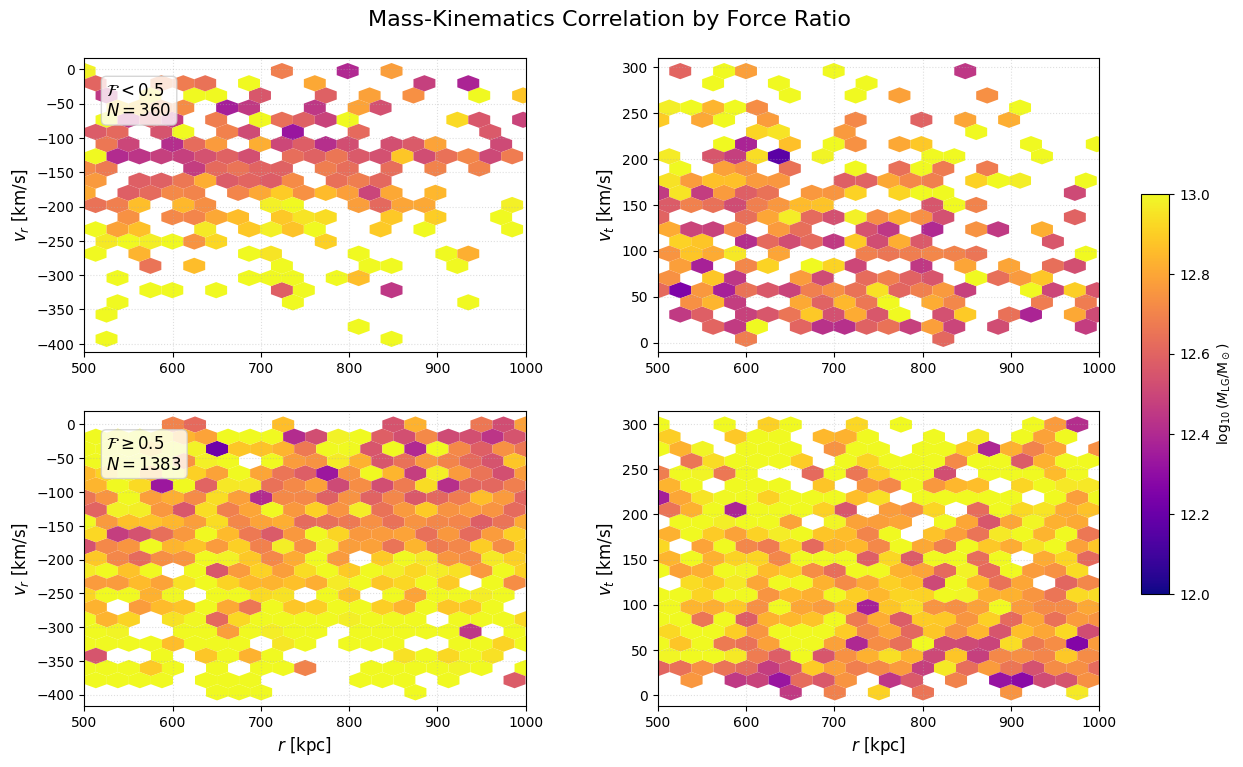

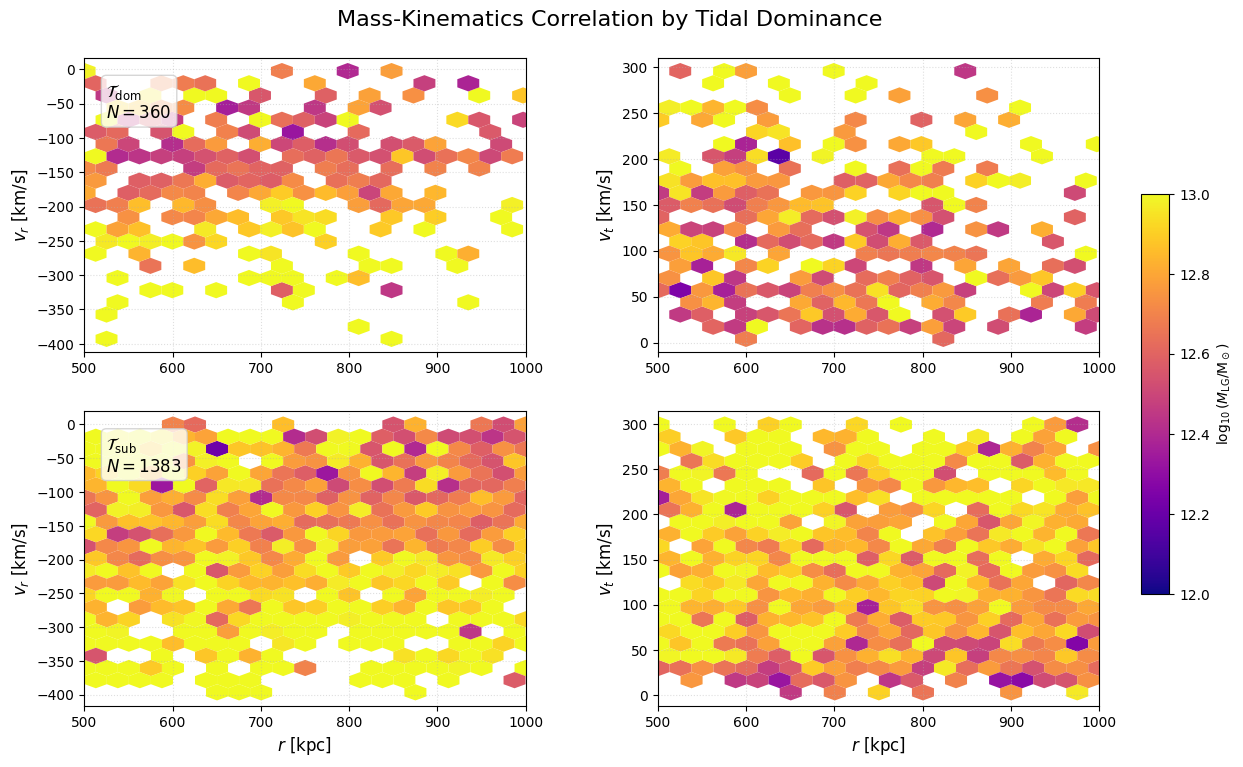

In [64]:
def build_kinematics_plots_hex(masks, legs, title):
    # Removing constrained_layout to manually control the title spacing
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    cmap = plt.get_cmap('plasma')
    
    # Define the global color scale limits as seen in the color bar
    v_min, v_max = 12.0, 13.0 #

    for row, (mask, leg) in enumerate(zip(masks, legs)):
        r = pairs.dist_kpc[mask]
        vr = pairs.v_r[mask]
        vt = pairs.v_t[mask]

        # Calculate LG mass for color mapping
        m_i = sub["SubhaloMass"][sample.keep_idx[pairs.i[mask]]].astype(np.float64) * 1e10 / h
        m_j = sub["SubhaloMass"][sample.keep_idx[pairs.j[mask]]].astype(np.float64) * 1e10 / h
        m_total_log = np.log10(m_i + m_j)

        # Plot Settings: gridsize controls the "bin" size. 20-30 is ideal for N ~ 2000.
        grid = 20

        # Column 0: Radial Velocity (vr) vs r
        hb_r = axes[row, 0].hexbin(r, vr, C=m_total_log, gridsize=grid, cmap=cmap, 
                                   vmin=v_min, vmax=v_max, mincnt=1, edgecolors='none')
        axes[row, 0].set_ylabel(r'$v_r$ [km/s]', fontsize=12)
        
        # Column 1: Transverse Velocity (vt) vs r
        hb_t = axes[row, 1].hexbin(r, vt, C=m_total_log, gridsize=grid, cmap=cmap, 
                                   vmin=v_min, vmax=v_max, mincnt=1, edgecolors='none')
        axes[row, 1].set_ylabel(r'$v_t$ [km/s]', fontsize=12)

        # Labels for rows (Categories)
        axes[row, 0].text(0.05, 0.92, f"{leg}\n$N = {len(r)}$", 
                        transform=axes[row, 0].transAxes, verticalalignment='top', fontsize=12,
                        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='0.8'))

    # Global Axis Formatting
    for ax in axes.flat:
        ax.set_xlim(500, 1000) #
        ax.grid(True, linestyle=':', alpha=0.4)

    for col in range(2):
        axes[1, col].set_xlabel(r'$r$ [kpc]', fontsize=12)

    # Colorbar and spacing
    fig.subplots_adjust(right=0.85, top=0.92, hspace=0.2, wspace=0.3)
    cbar_ax = fig.add_axes([0.88, 0.25, 0.02, 0.5])
    fig.colorbar(hb_t, cax=cbar_ax, label=r'$\log_{10}(M_{\mathrm{LG}} / \mathrm{M}_\odot)$')

    plt.suptitle(title, fontsize=16, y=0.98)
    plt.show()

# Execute updated plots
build_kinematics_plots_hex(f_masks, f_legs, "Mass-Kinematics Correlation by Force Ratio")
build_kinematics_plots_hex(f_masks, tid_legs, "Mass-Kinematics Correlation by Tidal Dominance")

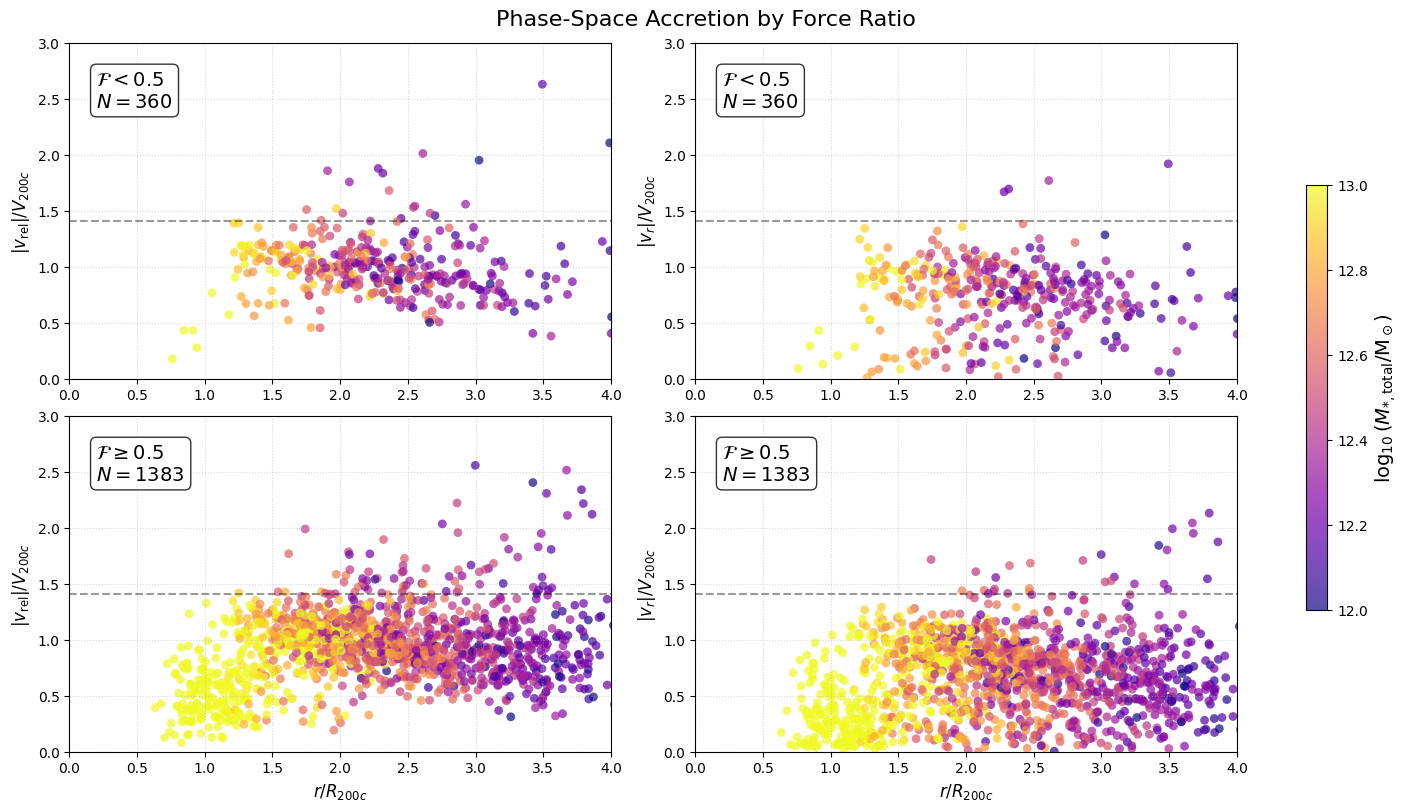

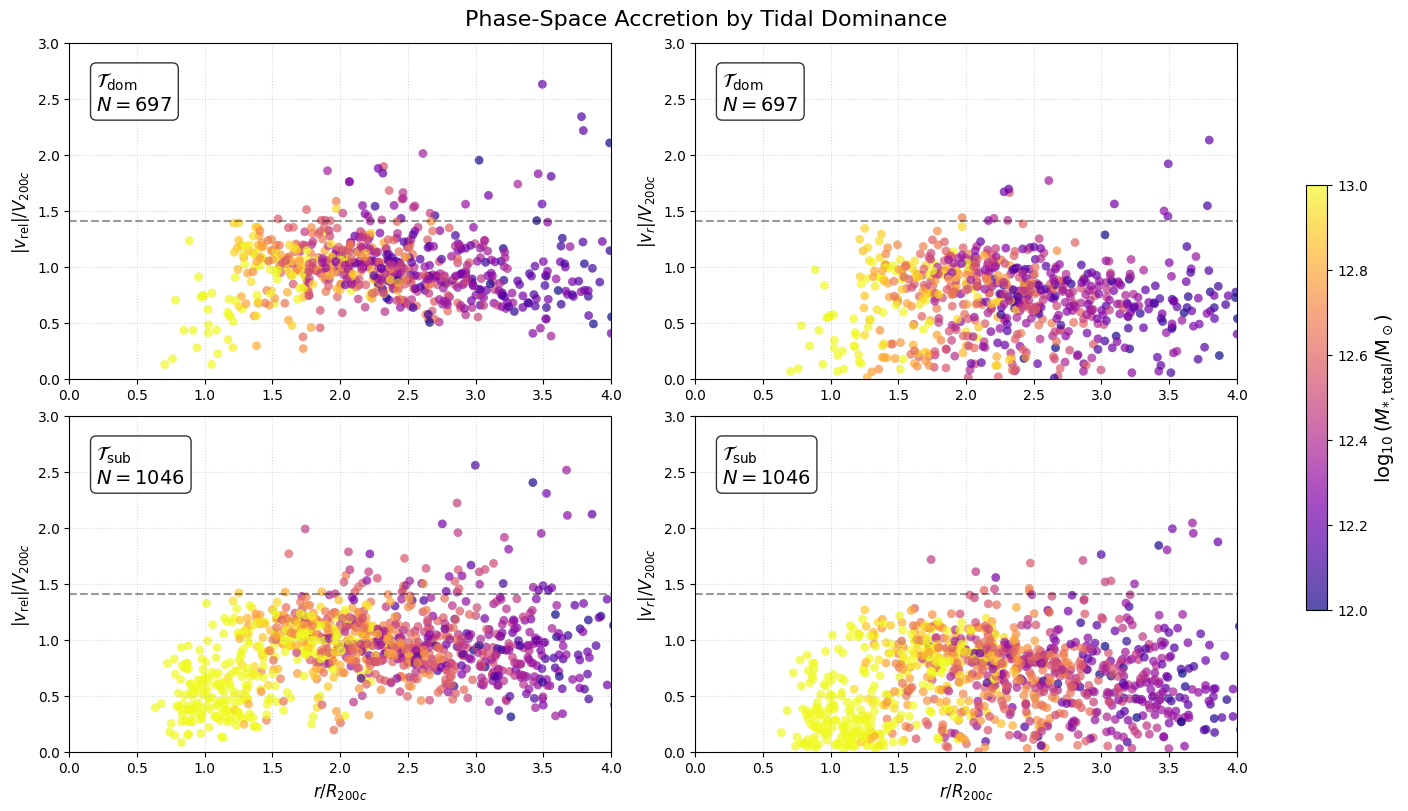

In [72]:
def build_phase_space_scatter(masks, legs, title, sample, pairs):
    """
    Produces a 2x2 grid of phase-space scatter plots (r/R200 vs v/V200)
    categorized by the provided masks.
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 8), constrained_layout=True)
    cmap = plt.get_cmap('plasma')
    
    # Indices for pair members in the Sample object
    idx_i = pairs.i
    idx_j = pairs.j

    for row, (mask, leg) in enumerate(zip(masks, legs)):
        # 1. Normalize Kinematics using the extended Sample class
        # Separation normalized by parent halo R200c
        r_norm = pairs.dist_kpc[mask] / sample.r200c[idx_i][mask]
        
        # Relative velocity normalized by parent halo V200c
        v_rel = np.sqrt(pairs.v_r[mask]**2 + pairs.v_t[mask]**2)
        v_norm = v_rel / sample.v200c[idx_i][mask]
        
        # Color by total pair mass (log10 Msun)
        m_total_log = np.log10(sample.m200c[idx_i][mask])

        # 2. Scatter Plot Logic
        # Left Column: Plot against Separation (r/R200)
        sc0 = axes[row, 0].scatter(r_norm, v_norm, c=m_total_log, s=40, alpha=0.7, 
                                   cmap=cmap, vmin=12.0, vmax=13.0, edgecolors='none')
        
        # Right Column: Plot against Radial Velocity (vr/V200) specifically for accretion detail
        vr_norm = np.abs(pairs.v_r[mask]) / sample.v200c[idx_i][mask]
        sc1 = axes[row, 1].scatter(r_norm, vr_norm, c=m_total_log, s=40, alpha=0.7, 
                                   cmap=cmap, vmin=12.0, vmax=13.0, edgecolors='none')

        # 3. Add Theoretical Boundaries
        for col in range(2):
            # Escape velocity line (V_esc ~ sqrt(2) * V200 at R200)
            axes[row, col].axhline(y=np.sqrt(2), color='black', linestyle='--', alpha=0.4)
            # Legend/Text box
            axes[row, col].text(0.05, 0.92, f"{leg}\n$N = {len(r_norm)}$", 
                                transform=axes[row, col].transAxes, verticalalignment='top',
                                fontsize=14, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # Formatting and Labels
    for ax in axes.flat:
        ax.set_xlim(0, 4)  # Focus on the host environment
        ax.set_ylim(0, 3)
        ax.grid(True, linestyle=':', alpha=0.5)

    axes[0, 0].set_ylabel(r'$|v_{\mathrm{rel}}| / V_{200c}$', fontsize=12)
    axes[1, 0].set_ylabel(r'$|v_{\mathrm{rel}}| / V_{200c}$', fontsize=12)
    axes[0, 1].set_ylabel(r'$|v_{r}| / V_{200c}$', fontsize=12)
    axes[1, 1].set_ylabel(r'$|v_{r}| / V_{200c}$', fontsize=12)
        
    for col in range(2):
        axes[1, col].set_xlabel(r'$r / R_{200c}$', fontsize=12)

    # Colorbar
    cb = fig.colorbar(sc0, ax=axes, location='right', shrink=0.6)
    cb.set_label(r'$\log_{10}(M_{*, \mathrm{total}} / \mathrm{M}_\odot)$', size=14)

    plt.suptitle(title, fontsize=16)
    plt.show()

# Run the plot
build_phase_space_scatter(f_masks, f_legs, "Phase-Space Accretion by Force Ratio", sample, pairs)
build_phase_space_scatter(tid_masks, tid_legs, "Phase-Space Accretion by Tidal Dominance", sample, pairs)

<>:5: SyntaxWarning: invalid escape sequence '\m'
<>:5: SyntaxWarning: invalid escape sequence '\m'
<>:24: SyntaxWarning: invalid escape sequence '\m'
<>:24: SyntaxWarning: invalid escape sequence '\m'
<>:43: SyntaxWarning: invalid escape sequence '\m'
<>:43: SyntaxWarning: invalid escape sequence '\m'
<>:5: SyntaxWarning: invalid escape sequence '\m'
<>:5: SyntaxWarning: invalid escape sequence '\m'
<>:24: SyntaxWarning: invalid escape sequence '\m'
<>:24: SyntaxWarning: invalid escape sequence '\m'
<>:43: SyntaxWarning: invalid escape sequence '\m'
<>:43: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_7267/3559659451.py:5: SyntaxWarning: invalid escape sequence '\m'
  legs = ['Isolated ($\mathcal{F} < 0.5$)', 'Perturbed ($\mathcal{F} \geq 0.5$)']
/tmp/ipykernel_7267/3559659451.py:5: SyntaxWarning: invalid escape sequence '\m'
  legs = ['Isolated ($\mathcal{F} < 0.5$)', 'Perturbed ($\mathcal{F} \geq 0.5$)']
/tmp/ipykernel_7267/3559659451.py:24: SyntaxWarning: invalid escap

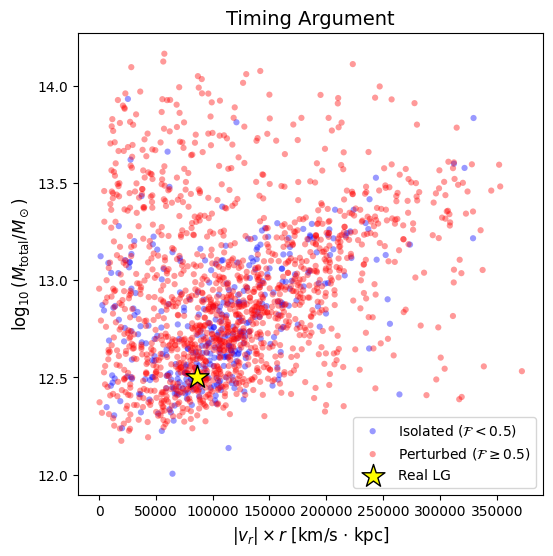

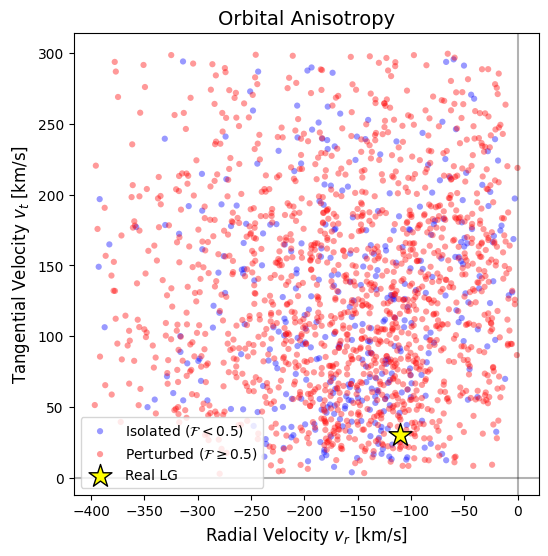

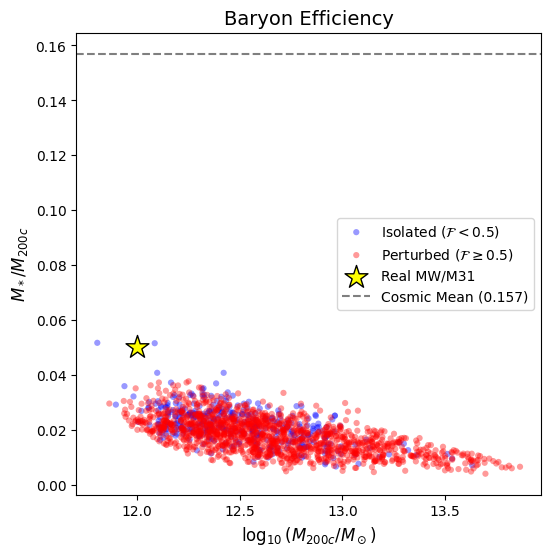

In [93]:
def plot_timing_argument(masks, sample, pairs):
    fig, ax = plt.subplots(figsize=(6, 6))
    # We explicitly define the colors for our two masks
    colors = ['blue', 'red']
    legs = ['Isolated ($\mathcal{F} < 0.5$)', 'Perturbed ($\mathcal{F} \geq 0.5$)']
    
    for mask, leg, col in zip(masks, legs, colors):
        m_total = sample.m200c[pairs.i[mask]] + sample.m200c[pairs.j[mask]]
        kinematic_term = np.abs(pairs.v_r[mask]) * pairs.dist_kpc[mask]
        ax.scatter(kinematic_term, np.log10(m_total), s=20, alpha=0.4, color=col, label=leg, edgecolors='none')

    # Real LG Reference: vr ~ -110 km/s, r ~ 780 kpc, Mass ~ 10^12.5 Msun
    ax.scatter(110 * 780, 12.5, color='yellow', marker='*', s=300, edgecolors='black', label='Real LG', zorder=5)
    
    ax.set_xlabel(r'$|v_r| \times r$ [km/s $\cdot$ kpc]', fontsize=12)
    ax.set_ylabel(r'$\log_{10}(M_{\mathrm{total}} / M_\odot)$', fontsize=12)
    ax.set_title("Timing Argument", fontsize=14)
    ax.legend()
    plt.show()

def plot_orbital_state(masks, pairs):
    fig, ax = plt.subplots(figsize=(6, 6))
    colors = ['blue', 'red']
    legs = ['Isolated ($\mathcal{F} < 0.5$)', 'Perturbed ($\mathcal{F} \geq 0.5$)']
    
    for mask, leg, col in zip(masks, legs, colors):
        ax.scatter(pairs.v_r[mask], pairs.v_t[mask], s=20, alpha=0.4, color=col, label=leg, edgecolors='none')

    # Real LG Reference: vr ~ -110 km/s, vt ~ 30 km/s
    ax.scatter(-110, 30, color='yellow', marker='*', s=300, edgecolors='black', label='Real LG', zorder=5)

    ax.set_xlabel(r'Radial Velocity $v_r$ [km/s]', fontsize=12)
    ax.set_ylabel(r'Tangential Velocity $v_t$ [km/s]', fontsize=12)
    ax.set_title("Orbital Anisotropy", fontsize=14)
    ax.axhline(0, color='black', alpha=0.3)
    ax.axvline(0, color='black', alpha=0.3)
    ax.legend()
    plt.show()

def plot_baryon_efficiency(masks, sample, pairs):
    fig, ax = plt.subplots(figsize=(6, 6))
    colors = ['blue', 'red']
    legs = ['Isolated ($\mathcal{F} < 0.5$)', 'Perturbed ($\mathcal{F} \geq 0.5$)']
    
    for mask, leg, col in zip(masks, legs, colors):
        # Using the primary subhalo (i) as the representative of the pair
        idx = pairs.i[mask]
        shmr = sample.mstar[idx] / sample.m200c[idx]
        ax.scatter(np.log10(sample.m200c[idx]), shmr, s=20, alpha=0.4, color=col, label=leg, edgecolors='none')

    # Real LG Reference: ~0.05 for Milky Way/M31 masses
    ax.scatter(12.0, 0.05, color='yellow', marker='*', s=300, edgecolors='black', label='Real MW/M31', zorder=5)
    
    # Cosmic Mean Reference
    ax.axhline(0.157, color='black', ls='--', alpha=0.5, label='Cosmic Mean (0.157)')
    
    ax.set_xlabel(r'$\log_{10}(M_{200c} / M_\odot)$', fontsize=12)
    ax.set_ylabel(r'$M_* / M_{200c}$', fontsize=12)
    ax.set_title("Baryon Efficiency", fontsize=14)
    ax.legend()
    plt.show()

plot_timing_argument(f_masks, sample, pairs)
plot_orbital_state(f_masks, pairs)
plot_baryon_efficiency(f_masks, sample, pairs)